In [97]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys


print("Current working directory:", os.getcwd())

Current working directory: /Users/Gourab/Downloads


In [98]:
downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "cavity_maser_N1.npz")

data = np.load(filename)

nh_values_l     = data["nh_values"]
G_over_kappa    = data["G_over_kappa"]
pop_g           = data["pop_g"]
pop_1           = data["pop_1"]
pop_2           = data["pop_2"]
navg_numeric    = data["navg_numeric"]
navg_analytic   = data["navg_analytic"]
g2_numeric      = data["g2_numeric"]
var_analytic    = data["var_analytic"]

nh_points_l     = data["nh_points"]
Pn_num_arr      = data["Pn_num_arr"]
Pn_an_arr       = data["Pn_an_arr"]
navg_fig3       = data["navg_fig3"]
g2_fig3         = data["g2_fig3"]
Wigner_arr      = data["Wigner_arr"]
xvec            = data["xvec"]

thresholds      = data["thresholds"]

kappa_saved   = float(data["kappa"])
g_saved       = float(data["g"])
gamma_h_saved = float(data["gamma_h"])
gamma_c_saved = float(data["gamma_c"])
nc_saved      = float(data["nc"])
n_max_saved   = int(data["n_max"])

In [99]:
print("--- sample points diagnostics ---")
n_range = np.arange(Pn_num_arr.shape[1])

for row, nh in enumerate(nh_points_l):
    navg_from_Pn_num = np.sum(n_range * Pn_num_arr[row])
    navg_from_Pn_an  = np.sum(n_range * Pn_an_arr[row])
    print(f"  n_h={nh:6.3f} | <n>_num={navg_fig3[row]:.4f} "
          f"(from Pn: {navg_from_Pn_num:.4f}) | "
          f"<n>_analytic(fromPn)={navg_from_Pn_an:.4f} | "
          f"g2(0)_num={g2_fig3[row]:.3f}")

--- sample points diagnostics ---
  n_h= 0.170 | <n>_num=0.9068 (from Pn: 0.9068) | <n>_analytic(fromPn)=0.9070 | g2(0)_num=1.287
  n_h= 0.507 | <n>_num=2.4162 (from Pn: 2.4162) | <n>_analytic(fromPn)=2.4197 | g2(0)_num=1.162
  n_h= 2.629 | <n>_num=4.3861 (from Pn: 4.3861) | <n>_analytic(fromPn)=4.3907 | g2(0)_num=1.133
  n_h= 9.000 | <n>_num=2.2231 (from Pn: 2.2231) | <n>_analytic(fromPn)=2.2554 | g2(0)_num=1.417


In [100]:
print("--- Photon statistics: variance/mean ratio (analytical, full sweep) ---")

ratio_var_mean = np.divide(
    var_analytic, navg_analytic,
    out=np.full_like(var_analytic, np.nan),
    where=navg_analytic > 1e-8
)

above_thr_mask = G_over_kappa >= 1.0
if np.any(above_thr_mask):
    print(f"  Above threshold range: n_h in "
          f"[{nh_values_l[above_thr_mask].min():.3f}, "
          f"{nh_values_l[above_thr_mask].max():.3f}]")
    print(f"  Mean variance/mean ratio above threshold: "
          f"{np.nanmean(ratio_var_mean[above_thr_mask]):.3f} "
          f"(>1 => super-Poissonian, =1 => Poissonian)")
else:
    print("  No points above threshold in this sweep.")

--- Photon statistics: variance/mean ratio (analytical, full sweep) ---
  Above threshold range: n_h in [0.306, 8.542]
  Mean variance/mean ratio above threshold: 1.850 (>1 => super-Poissonian, =1 => Poissonian)


## Plot: Gain, populations, cavity photon number

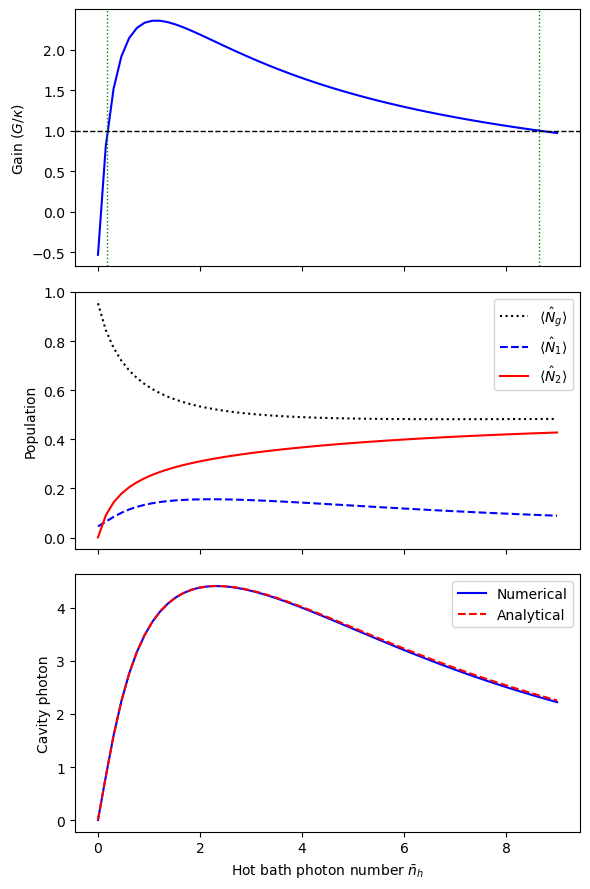

In [101]:
fig, axes = plt.subplots(3, 1, figsize=(6, 9), sharex=True)

axes[0].plot(nh_values_l, G_over_kappa, 'b-')
axes[0].axhline(1.0, color='k', ls='--', lw=1)
for th in thresholds:
    axes[0].axvline(th, color='g', ls=':', lw=1)
axes[0].set_ylabel(r'Gain $(G/\kappa)$')


axes[1].plot(nh_values_l, pop_g, 'k:', label=r'$\langle \hat N_g\rangle$')
axes[1].plot(nh_values_l, pop_1, 'b--', label=r'$\langle \hat N_1\rangle$')
axes[1].plot(nh_values_l, pop_2, 'r-', label=r'$\langle \hat N_2\rangle$')
axes[1].set_ylabel('Population')
axes[1].legend()

axes[2].plot(nh_values_l, navg_numeric, 'b-', label='Numerical')
axes[2].plot(nh_values_l, navg_analytic, 'r--', label='Analytical')
axes[2].set_ylabel(r'Cavity photon')
axes[2].set_xlabel(r'Hot bath photon number $\bar n_h$')
axes[2].legend()

plt.tight_layout()
plt.show()

## Plot: $g^{(2)}(0)$ vs $\bar n_h$ 

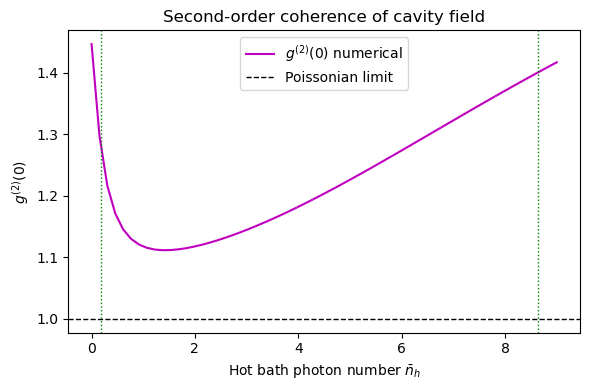

In [102]:
fig_g2, ax_g2 = plt.subplots(figsize=(6, 4))
ax_g2.plot(nh_values_l, g2_numeric, 'm-', label=r'$g^{(2)}(0)$ numerical')
ax_g2.axhline(1.0, color='k', ls='--', lw=1, label='Poissonian limit')
for th in thresholds:
    ax_g2.axvline(th, color='g', ls=':', lw=1)
ax_g2.set_xlabel(r'Hot bath photon number $\bar n_h$')
ax_g2.set_ylabel(r'$g^{(2)}(0)$')
ax_g2.set_title('Second-order coherence of cavity field')
ax_g2.legend()
plt.tight_layout()
plt.show()

## Plot: photon number distributions & Wigner functions

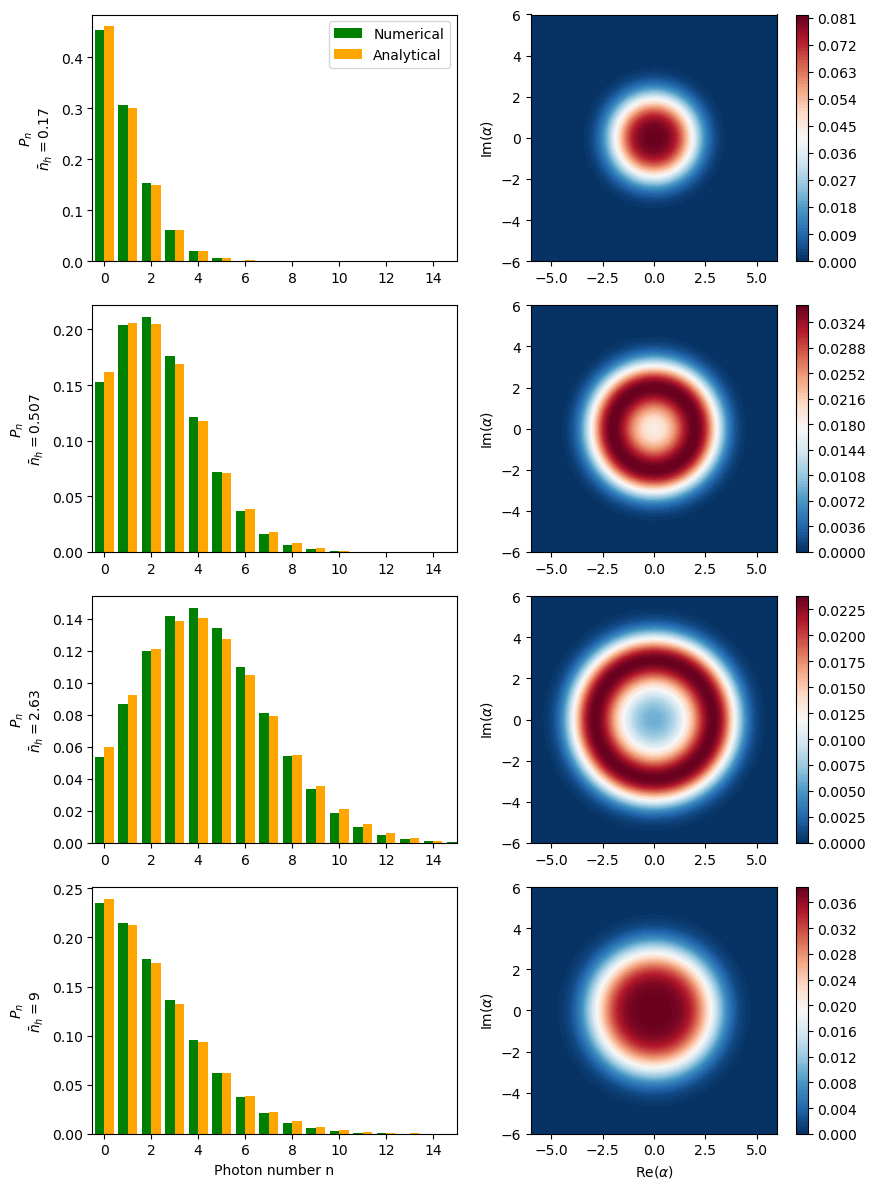

In [103]:
fig3, axes3 = plt.subplots(len(nh_points_l), 2, figsize=(9, 12))

for row, nh in enumerate(nh_points_l):
    width = 0.4
    axes3[row, 0].bar(n_range - width/2, Pn_num_arr[row], width=width,
                       color='green', label='Numerical')
    axes3[row, 0].bar(n_range + width/2, Pn_an_arr[row], width=width,
                       color='orange', label='Analytical')
    axes3[row, 0].set_xlim(-0.5, 15)
    axes3[row, 0].set_ylabel(f"$P_n$\n" + r"$\bar n_h=$" + f"{nh:.3g}")
    if row == 0:
        axes3[row, 0].legend()
    if row == len(nh_points_l) - 1:
        axes3[row, 0].set_xlabel("Photon number n")

    im = axes3[row, 1].contourf(xvec, xvec, Wigner_arr[row], 100, cmap='RdBu_r')
    axes3[row, 1].set_aspect('equal')
    if row == len(nh_points_l) - 1:
        axes3[row, 1].set_xlabel("Re($\\alpha$)")
    axes3[row, 1].set_ylabel("Im($\\alpha$)")
    fig3.colorbar(im, ax=axes3[row, 1])

plt.tight_layout()
plt.show()

## zoomed-in view near each threshold

Useful for visually confirming the exact location of the two critical points where $G/\kappa$ crosses 1.

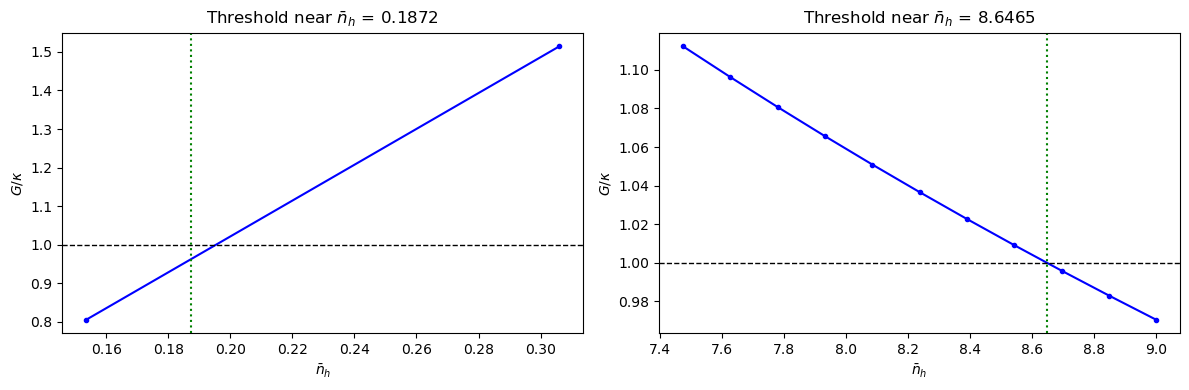

In [104]:
if len(thresholds) > 0:
    fig_zoom, axes_zoom = plt.subplots(1, len(thresholds), figsize=(6 * len(thresholds), 4))
    if len(thresholds) == 1:
        axes_zoom = [axes_zoom]

    for ax, th in zip(axes_zoom, thresholds):
        window = 0.15 * max(th, 1.0)
        mask = (nh_values_l > th - window) & (nh_values_l < th + window)
        ax.plot(nh_values_l[mask], G_over_kappa[mask], 'b.-')
        ax.axhline(1.0, color='k', ls='--', lw=1)
        ax.axvline(th, color='g', ls=':', lw=1.5)
        ax.set_title(f"Threshold near $\\bar n_h$ = {th:.4f}")
        ax.set_xlabel(r'$\bar n_h$')
        ax.set_ylabel(r'$G/\kappa$')

    plt.tight_layout()
    plt.show()
else:
    print("No thresholds found in this sweep range.")

## variance-to-mean ratio across the sweep (photon statistics)

Shows where the field is sub-Poissonian, Poissonian, or super-Poissonian.

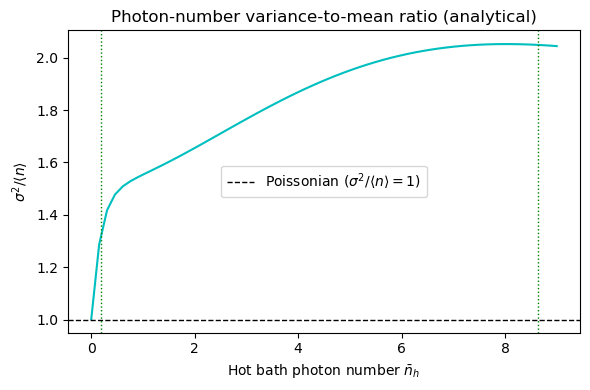

In [105]:
fig_stat, ax_stat = plt.subplots(figsize=(6, 4))
ax_stat.plot(nh_values_l, ratio_var_mean, 'c-')
ax_stat.axhline(1.0, color='k', ls='--', lw=1, label='Poissonian ($\\sigma^2/\\langle n\\rangle = 1$)')
for th in thresholds:
    ax_stat.axvline(th, color='g', ls=':', lw=1)
ax_stat.set_xlabel(r'Hot bath photon number $\bar n_h$')
ax_stat.set_ylabel(r'$\sigma^2 / \langle n \rangle$')
ax_stat.set_title('Photon-number variance-to-mean ratio (analytical)')
ax_stat.legend()
plt.tight_layout()
plt.show()